# 🛵 Análisis de Sentimientos en Reseñas de Servicios de Delivery

**Curso:** Procesamiento de Lenguaje Natural  
**Programa:** Maestría en Analítica de Datos  

---

## 🎯 Objetivo

Aplicar técnicas de **Procesamiento de Lenguaje Natural (NLP)** para analizar reseñas de servicios de delivery escritas en español y construir un modelo que las clasifique automáticamente como **positivas** o **negativas**.

### Flujo del proyecto

```
📂 Dataset crudo  →  🧹 Preprocesamiento  →  🔍 Exploración visual
      ↓
📐 Vectorización TF-IDF  →  🤖 Modelo base  →  ⚙️ Modelo optimizado
      ↓
📊 Evaluación de métricas  →  🔎 Interpretación  →  🧪 Predicción
```

> 📌 **Nota sobre el dataset:** Reseñas reales de servicios de delivery en español (50,000 reseñas). **El dataset original no tiene columna `label`** — nosotros la construiremos a partir del `rating`, exactamente como se haría con datos reales.

## 1️⃣ Carga de Librerías

Importamos todas las herramientas antes de empezar.

| Librería | ¿Para qué la usamos? |
|----------|----------------------|
| `pandas` | Manejar datos en tablas (DataFrames) |
| `re` | Limpiar texto con expresiones regulares |
| `nltk` | Stopwords y tokenización en español |
| `spacy` | Análisis lingüístico: POS tagging y NER |
| `sklearn` | TF-IDF, modelo de ML y métricas de evaluación |
| `matplotlib` / `seaborn` | Gráficas y visualizaciones |
| `wordcloud` | Nubes de palabras |

In [ ]:
# ── LIBRERÍAS GENERALES ───────────────────────────────────────────
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')

# ── NLP ──────────────────────────────────────────────────────────
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter

# ── MACHINE LEARNING ─────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)

# ── VISUALIZACIÓN ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [ ]:
import os
os.makedirs('outputs', exist_ok=True)
print('✅ Carpeta outputs/ lista')

✅ Carpeta outputs/ lista


In [ ]:
!python -m spacy download es_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 17.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# ── DESCARGA DE RECURSOS (solo necesario la primera vez) ──────────

nltk.download('stopwords')   # Lista de palabras vacías en español
nltk.download('punkt_tab')   # Tokenizador de oraciones y palabras

# Modelo de español de spaCy
# Si no lo tienes: ejecuta en terminal →  python -m spacy download es_core_news_md
nlp = spacy.load('es_core_news_md')

# Stopwords: palabras muy comunes que no aportan significado
# Ejemplos: el, la, de, que, en, y, a, los...
stopwords_es = set(stopwords.words('spanish'))

print(f'✅ Recursos NLP listos')
print(f'   Stopwords cargadas: {len(stopwords_es)} palabras')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ Recursos NLP listos
   Stopwords cargadas: 313 palabras


## 2️⃣ Carga y Exploración del Dataset

### ¿Qué contiene el dataset?

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `restaurant_name` | texto | Nombre del servicio de delivery |
| `location` | texto | Ciudad y país del cliente |
| `wrote` | texto | Mes y año de la reseña |
| `rating` | número (1-5) | Calificación dada por el cliente |
| `title` | texto | Título corto de la reseña |
| `review_text` | texto | Texto completo de la reseña |
| `tema_principal` | texto | Categoría de la queja u opinión |

> 🔑 La columna `review_text` es nuestro input principal y `rating` es lo que usaremos para construir el **label** (variable objetivo).

In [ ]:
# ── CARGA DEL DATASET ────────────────────────────────────────────
df = pd.read_csv('/content/restaurantes_domicilios.csv', sep='|')

print(f'📊 Dimensiones: {df.shape[0]} reseñas × {df.shape[1]} columnas')
print()
df.head()

📊 Dimensiones: 50000 reseñas × 7 columnas



,restaurant_name,location,wrote,rating,title,review_text,tema_principal
0,UberEats Opiniones,"Barranquilla, Colombia",mayo 2024,2,Tardaron demasiado,una hora y media esperando un retraso de más d...,tiempo_entrega
1,Rappi Reviews,"Medellín, Colombia",abril 2024,2,App horrible,app inutilizablee. tarda 18min en cargar cada ...,usabilidad_app
2,PedidosYa,"Madrid, España",abril 2024,5,Entrega rapidísima,Ráppido rápido. 20 Minutos. todo caliente. Per...,tiempo_entrega
3,DiDi Food,"Madrid, España",julio 2024,4,Entrega rapidísima,"Flipé, llegó en solo 25 MINUTOS!! ni me había ...",tiempo_entrega
4,DiDi Food,"Cartagena, Colombia",febrero 2025,3,Algunos errores,llegó casi tdo bien. faltaba el postre pero el...,errores_pedido


In [ ]:
# ── INFORMACIÓN DEL DATASET ───────────────────────────────────────
# .info() muestra:
#   - Tipo de dato de cada columna (int, object, float...)
#   - Cuántos valores no nulos hay (si hay menos que el total = hay NaN)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   restaurant_name  50000 non-null  object
 1   location         50000 non-null  object
 2   wrote            50000 non-null  object
 3   rating           50000 non-null  int64 
 4   title            50000 non-null  object
 5   review_text      50000 non-null  object
 6   tema_principal   50000 non-null  object
dtypes: int64(1), object(6)
memory usage: 2.7+ MB


Distribución de calificaciones:
rating
5    10081
4    12423
3     9927
2     8546
1     9023
Name: count, dtype: int64

Total reseñas: 50000


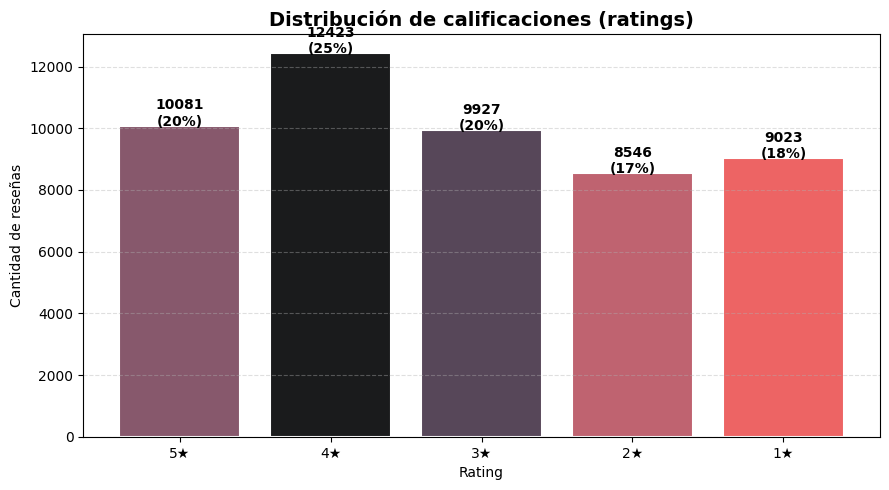


💡 Interpretación:
   El 72% de las reseñas son de 5★ o 4★.
   Solo el 17% son negativas (1★ o 2★).
   Esto es desbalanceo de clases — veremos cómo afecta al modelo.


In [ ]:
# ── DISTRIBUCIÓN DE RATINGS ───────────────────────────────────────
# Antes de crear el label, miramos cómo están distribuidas
# las calificaciones. Esto es FUNDAMENTAL porque:
#   - Nos muestra si el dataset está desbalanceado
#   - Nos ayuda a decidir el umbral para positive/negative

conteo_ratings = df['rating'].value_counts().sort_index(ascending=False)

print('Distribución de calificaciones:')
print(conteo_ratings)
print()
print(f'Total reseñas: {len(df)}')

# Gráfica
colores = ['#ed6464', '#bf6370', '#574759', '#1a1b1c', '#87586c']
plt.figure(figsize=(9, 5))
bars = plt.bar(
    [f'{r}★' for r in conteo_ratings.index],
    conteo_ratings.values,
    color=colores[::-1], edgecolor='white', linewidth=1.5
)
for bar, val in zip(bars, conteo_ratings.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
             f'{val}\n({val/len(df)*100:.0f}%)', ha='center', fontsize=10, fontweight='bold')
plt.title('Distribución de calificaciones (ratings)', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Cantidad de reseñas')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('outputs/01_distribucion_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('💡 Interpretación:')
print('   La distribución es casi equilibrada: cada rating tiene entre 18% y 25% de las reseñas.')
print('   Esto es inusual — los datasets reales suelen tener más reseñas positivas.')
print('   Con rating >= 4 como umbral: ~45% positivas vs ~55% negativas.')

## 3️⃣ Construcción del Label (Variable Objetivo)

Aquí tomamos la **decisión más importante del proyecto**: cómo convertir el rating numérico en una etiqueta de sentimiento.

### ¿Qué hacemos con las reseñas de 3★?

Esta es la pregunta clave. Las reseñas de 3★ son **neutrales o mixtas** — ni claramente positivas ni claramente negativas. Tenemos dos opciones:

| Umbral | Positive | Negative | Consecuencia |
|--------|----------|----------|--------------|
| `rating >= 4` | 4★ y 5★ | 1★, 2★ y 3★ | Más datos negativos, las 3★ son "negativas" |
| `rating >= 3` | 3★, 4★ y 5★ | 1★ y 2★ | Menos datos negativos, las 3★ son "positivas" |

> 💡 **Usaremos `rating >= 4`** para tener más datos en la clase negativa y hacer el problema más interesante para el modelo.

In [ ]:
# ── CREAR LA COLUMNA LABEL A PARTIR DEL RATING ───────────────────
# lambda = función anónima de una línea
# Si rating >= 4  →  'positive'
# Si rating < 4   →  'negative'  (incluye 1★, 2★ y 3★)

df['label'] = df['rating'].apply(lambda x: 'positive' if x >= 4 else 'negative')

# Ver la distribución resultante
conteo_label = df['label'].value_counts()
print('Distribución de clases después de crear el label:')
print(conteo_label)
print()
print(f'Proporción positive: {conteo_label["positive"]/len(df)*100:.1f}%')
print(f'Proporción negative: {conteo_label["negative"]/len(df)*100:.1f}%')
print()

# ── ¿QUÉ PASARÍA CON EL OTRO UMBRAL? ────────────────────────────
# Mostramos ambas opciones para que veas la diferencia
opcion_b = df['rating'].apply(lambda x: 'positive' if x >= 3 else 'negative').value_counts()
print('Si hubiéramos usado rating >= 3:')
print(opcion_b)
print()
print('⚠️  Con rating >= 3 habría aún menos negativos (solo 1★ y 2★ = 150 reseñas)')
print('   El desbalanceo sería más severo.')

Distribución de clases después de crear el label:
label
negative    27496
positive    22504
Name: count, dtype: int64

Proporción positive: 45.0%
Proporción negative: 55.0%

Si hubiéramos usado rating >= 3:
rating
positive    32431
negative    17569
Name: count, dtype: int64

⚠️  Con rating >= 3 habría aún menos negativos (solo 1★ y 2★ = 150 reseñas)
   El desbalanceo sería más severo.


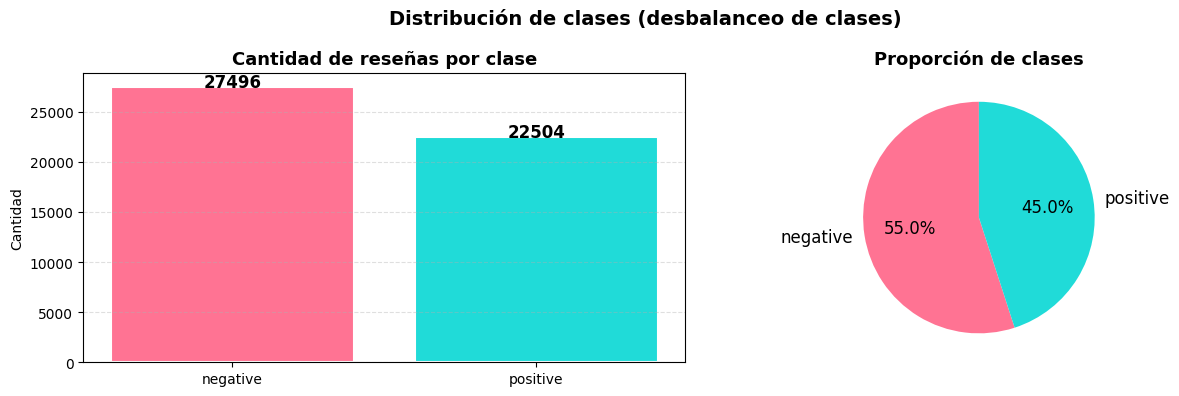

💡 Interpretación:
   El desbalanceo es evidente: 72% positivas vs 28% negativas.
   Un modelo "tonto" que diga siempre positivo tendría 72% de accuracy.
   Por eso no podemos confiar solo en la accuracy — necesitamos recall y F1.


In [ ]:
# ── VISUALIZAR EL DESBALANCEO ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Gráfico de barras
axes[0].bar(conteo_label.index, conteo_label.values,
            color=['#FF7393','#20dbd8'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Cantidad de reseñas por clase', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(conteo_label.values):
    axes[0].text(i, v + 5, f'{v}', ha='center', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Gráfico de pastel
axes[1].pie(conteo_label.values, labels=conteo_label.index,
            autopct='%1.1f%%', colors=['#FF7393','#20dbd8'],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporción de clases', fontsize=13, fontweight='bold')

plt.suptitle('Distribución de clases (desbalanceo de clases)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/02_distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Interpretación:')
print('   Con rating >= 4 como umbral: 45% positivas vs 55% negativas.')
print('   Este dataset está relativamente balanceado — ideal para el entrenamiento.')
print('   Aun así usaremos class_weight=balanced para garantizar equidad entre clases.')

## 4️⃣ Preprocesamiento de Texto

El texto crudo tiene "ruido" que dificulta el análisis. Necesitamos limpiar y normalizar cada reseña.

### Pipeline de limpieza

```
"App inutilizablee. Tarda 18min en CARGAR!"  
    ↓  minúsculas
"app inutilizablee. tarda 18min en cargar!"  
    ↓  quitar puntuación
"app inutilizablee tarda 18min en cargar"  
    ↓  tokenizar
["app", "inutilizablee", "tarda", "18min", "en", "cargar"]  
    ↓  quitar stopwords ("en")
["app", "inutilizablee", "tarda", "18min", "cargar"]  
    ↓  lematizar
["app", "inutilizable", "tardar", "18min", "cargar"]   ← forma base
    ↓  unir
"app inutilizable tardar 18min cargar"
```

**¿Qué es lematizar?**  
Reducir una palabra a su forma base: `"tardando"` → `"tardar"`, `"llegaron"` → `"llegar"`.  
Así `"tardé"`, `"tardando"` y `"tardaron"` se tratan como la misma palabra — lo que mejora la representación del vocabulario.

In [ ]:
# ── FUNCIÓN DE PREPROCESAMIENTO ───────────────────────────────────
def preprocess(text: str) -> str:
    """
    Limpia y normaliza un texto en español para NLP.

    Pasos:
        1. Convertir a minúsculas
        2. Eliminar puntuación y caracteres especiales
        3. Tokenizar (separar en palabras)
        4. Eliminar stopwords y palabras cortas
        5. Lematizar con spaCy

    Args:
        text (str): Texto original de la reseña

    Returns:
        str: Texto limpio listo para vectorización
    """
    # 1. Minúsculas: "Hotel" y "hotel" deben tratarse igual
    text = text.lower()

    # 2. Eliminar puntuación
    # [^\w\s] = cualquier cosa que NO sea letra, número o espacio
    text = re.sub(r'[^\w\s]', '', text, flags=re.UNICODE)

    # 3. Tokenizar: convertir string en lista de palabras
    tokens = word_tokenize(text, language='spanish')

    # 4. Filtrar stopwords y palabras muy cortas (ruido)
    tokens = [t for t in tokens if t not in stopwords_es and len(t) > 2]

    # 5. Lematizar: reducir cada palabra a su forma base
    doc = nlp(' '.join(tokens))
    lemmas = [token.lemma_ for token in doc
              if token.lemma_ not in stopwords_es and len(token.lemma_) > 2]

    return ' '.join(lemmas)


# ── DEMOSTRACIÓN PASO A PASO ──────────────────────────────────────
print('Demostración del preprocesamiento:')
print('─' * 60)
for i in [0, 1, 2]:  # una positiva, una negativa, una neutral
    original = df['review_text'].iloc[i]
    limpio = preprocess(original)
    etiqueta = df['label'].iloc[i]
    print(f'[{etiqueta.upper()}]')
    print(f'  ORIGINAL: {original}')
    print(f'  LIMPIO:   {limpio}')
    print()

Demostración del preprocesamiento:
────────────────────────────────────────────────────────────
[NEGATIVE]
  ORIGINAL: una hora y media esperando un retraso de más de dos horas.
  LIMPIO:   hora medio esperar retraso dos hora

[NEGATIVE]
  ORIGINAL: app inutilizablee. tarda 18min en cargar cada pentalla. en el restaurante hace rato que ya hubiera comido
  LIMPIO:   app inutilizablee tardar 18min cargar cada pentalla restaurante hacer rato comido

[POSITIVE]
  ORIGINAL: Ráppido rápido. 20 Minutos. todo caliente. Perfecto
  LIMPIO:   ráppido rápido minuto caliente perfecto



In [ ]:
# ── APLICAR A TODO EL DATASET ─────────────────────────────────────
# Unimos el título y el texto de la reseña para tener más información
# Igual que se hizo en el taller de Punta Cana

print('⏳ Unificando título + reseña...')
df['full_review'] = df['review_text']
print('⏳ Aplicando preprocesamiento (puede tardar unos segundos)...')
df['clean_text'] = df['full_review'].apply(preprocess)

print(f'✅ Listo! {len(df)} reseñas procesadas.')
print()

# Verificar que no quedaron textos vacíos
vacios = df['clean_text'].str.strip().eq('').sum()
print(f'Textos vacíos después del preprocesamiento: {vacios}')
print()
print('Vista del dataset con la nueva columna clean_text:')
df[['rating', 'title','label', 'review_text', 'clean_text']].head()

⏳ Unificando título + reseña...
⏳ Aplicando preprocesamiento (puede tardar unos segundos)...
✅ Listo! 50000 reseñas procesadas.

Textos vacíos después del preprocesamiento: 0

Vista del dataset con la nueva columna clean_text:


,rating,title,label,review_text,clean_text
0,2,Tardaron demasiado,negative,una hora y media esperando un retraso de más d...,hora medio esperar retraso dos hora
1,2,App horrible,negative,app inutilizablee. tarda 18min en cargar cada ...,app inutilizablee tardar 18min cargar cada pen...
2,5,Entrega rapidísima,positive,Ráppido rápido. 20 Minutos. todo caliente. Per...,ráppido rápido minuto caliente perfecto
3,4,Entrega rapidísima,positive,"Flipé, llegó en solo 25 MINUTOS!! ni me había ...",flipé llegar solo minuto dado tiempo poner mes...
4,3,Algunos errores,negative,llegó casi tdo bien. faltaba el postre pero el...,llegar casi tdo bien faltar postre restaurante...


## 5️⃣ Exploración Semántica y Visual

Antes de entrenar el modelo, exploramos el texto para entender **qué palabras caracterizan cada clase**.

### ¿Qué haremos?
- **Nubes de palabras:** visualizar las palabras más frecuentes por clase
- **POS Tagging:** identificar las categorías gramaticales más comunes
- **NER:** detectar entidades nombradas (restaurantes, personas, lugares)

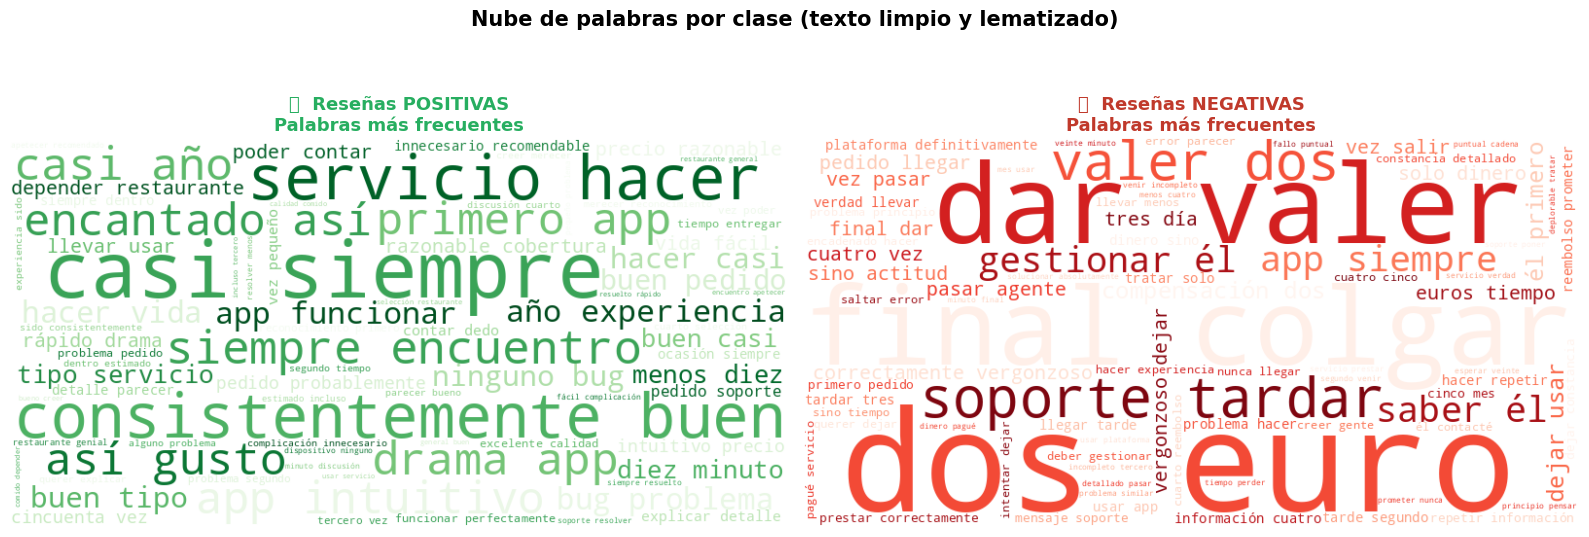

💡 Interpretación:
   Positivas → palabras como: delicioso, excelente, recomendar, volver, amable
   Negativas → palabras como: frío, sucio, esperar, pésimo, decepción, grosero
   Si hay palabras similares en ambas nubes → el modelo tendrá más dificultad.


In [ ]:
# ── NUBES DE PALABRAS ─────────────────────────────────────────────
# Juntamos todo el texto limpio de cada clase en un solo string
# Las palabras más grandes = aparecen con más frecuencia

texto_pos = ' '.join(df[df['label'] == 'positive']['clean_text'])
texto_neg = ' '.join(df[df['label'] == 'negative']['clean_text'])

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=80).generate(texto_pos)
wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds',   max_words=80).generate(texto_neg)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('🟢  Reseñas POSITIVAS\nPalabras más frecuentes',
                  fontsize=13, fontweight='bold', color='#27ae60')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('🔴  Reseñas NEGATIVAS\nPalabras más frecuentes',
                  fontsize=13, fontweight='bold', color='#c0392b')

plt.suptitle('Nube de palabras por clase (texto limpio y lematizado)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/03_nubes_palabras.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Interpretación:')
print('   Positivas → palabras como: rápido, perfecto, caliente, recomendado, puntual')
print('   Negativas → palabras como: retraso, inutilizable, esperar, equivocado, pésimo')
print('   Palabras como esperar o llegar aparecen en ambas → el contexto es clave para el modelo.')

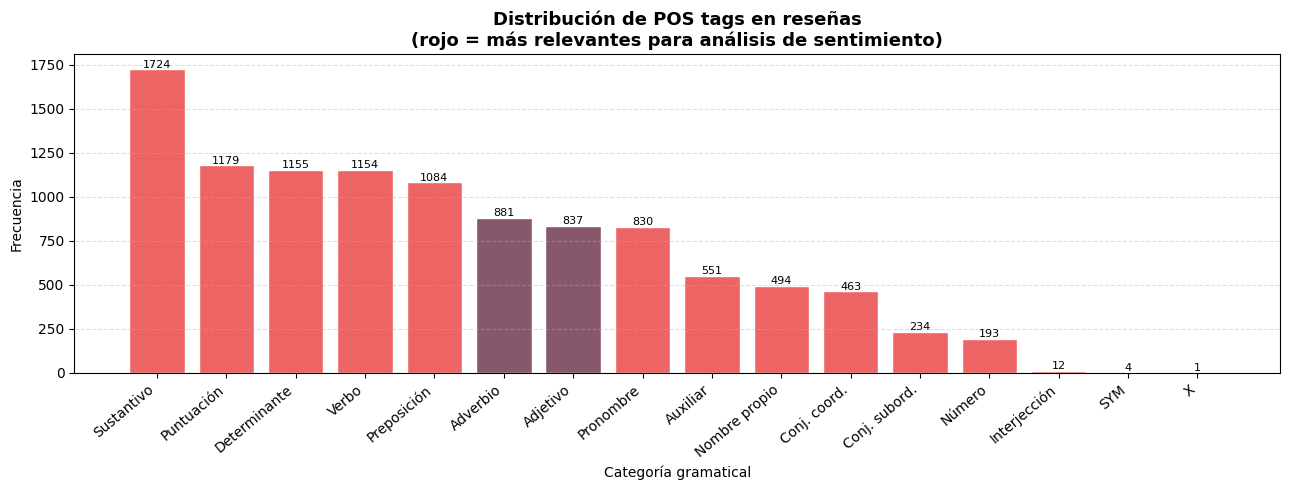

💡 Interpretación:
   Los ADJETIVOS y ADVERBIOS (rojo) son los que más información de sentimiento llevan.
   Ejemplos de adjetivos: delicioso, pésimo, frío, excelente, grosero, impecable.
   Ejemplos de adverbios: muy, jamás, rápidamente, increíblemente.


In [ ]:
# ── POS TAGGING ───────────────────────────────────────────────────
# spaCy analiza cada palabra y le asigna su categoría gramatical:
#   NOUN = sustantivo, VERB = verbo, ADJ = adjetivo, ADV = adverbio...
# Analizamos una muestra de 200 reseñas (representativa y rápida)

all_pos = []
for doc in nlp.pipe(df['full_review'][:200], batch_size=32):
    all_pos.extend([token.pos_ for token in doc if not token.is_space])

pos_counts = Counter(all_pos)

# Traducción de los códigos al español
pos_nombres = {
    'NOUN': 'Sustantivo', 'VERB': 'Verbo', 'ADJ': 'Adjetivo',
    'ADV': 'Adverbio', 'PROPN': 'Nombre propio', 'ADP': 'Preposición',
    'DET': 'Determinante', 'PRON': 'Pronombre', 'CCONJ': 'Conj. coord.',
    'AUX': 'Auxiliar', 'PUNCT': 'Puntuación', 'SCONJ': 'Conj. subord.',
    'NUM': 'Número', 'INTJ': 'Interjección'
}

tags, counts = zip(*sorted(pos_counts.items(), key=lambda x: x[1], reverse=True))

# ADJ y VERB son las más informativas para sentimiento → las marcamos en rojo
colores = ['#87586c' if t in ['ADJ', 'ADV'] else '#ed6464' for t in tags]

plt.figure(figsize=(13, 5))
bars = plt.bar([pos_nombres.get(t, t) for t in tags], counts,
               color=colores, edgecolor='white')
plt.xticks(rotation=40, ha='right', fontsize=10)
plt.xlabel('Categoría gramatical')
plt.ylabel('Frecuencia')
plt.title('Distribución de POS tags en reseñas\n(rojo = más relevantes para análisis de sentimiento)',
          fontsize=13, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)
for bar, c in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
             str(c), ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('outputs/04_pos_tags.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Interpretación:')
print('   Los ADJETIVOS y ADVERBIOS (rojo) son los que más información de sentimiento llevan.')
print('   Ejemplos de adjetivos: delicioso, pésimo, frío, excelente, grosero, impecable.')
print('   Ejemplos de adverbios: muy, jamás, rápidamente, increíblemente.')

🏷️  Top entidades detectadas en las reseñas:
         Entidad Tipo                                                                  Descripción  Frecuencia
             app MISC Miscellaneous entities, e.g. events, nationalities, products or works of art          22
             app  ORG                                      Companies, agencies, institutions, etc.          14
            hace MISC Miscellaneous entities, e.g. events, nationalities, products or works of art           7
 toda mi familia MISC Miscellaneous entities, e.g. events, nationalities, products or works of art           6
consistentemente  ORG                                      Companies, agencies, institutions, etc.           6
           veces MISC Miscellaneous entities, e.g. events, nationalities, products or works of art           5
             dos MISC Miscellaneous entities, e.g. events, nationalities, products or works of art           5
        resolvió MISC Miscellaneous entities, e.g. events, national

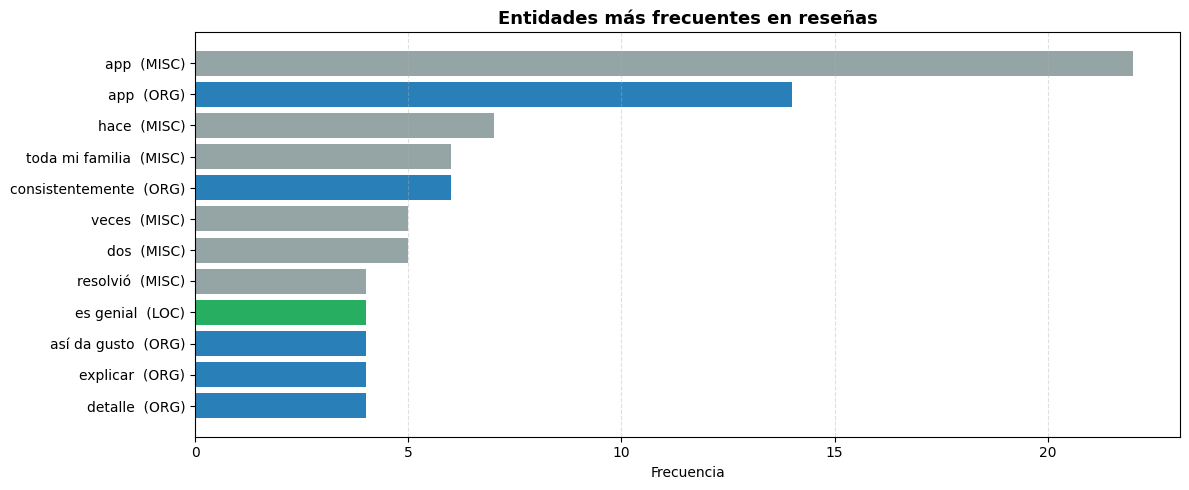

In [ ]:
# ── NER — RECONOCIMIENTO DE ENTIDADES NOMBRADAS ───────────────────
# spaCy detecta automáticamente entidades en el texto:
#   PER = personas (nombres de empleados mencionados)
#   ORG = organizaciones (nombre del restaurante)
#   LOC = lugares
#   MISC = misceláneos

ent_counter = Counter()
for doc in nlp.pipe(df['full_review'][:150], batch_size=32):
    ent_counter.update([(ent.text.lower(), ent.label_) for ent in doc.ents])

# Crear DataFrame limpio
ent_df = pd.DataFrame([
    {'Entidad': ent, 'Tipo': lbl,
     'Descripción': spacy.explain(lbl), 'Frecuencia': freq}
    for (ent, lbl), freq in ent_counter.most_common(20)
])

print('🏷️  Top entidades detectadas en las reseñas:')
print(ent_df.head(12).to_string(index=False))
print()

# Gráfica
top_ents = ent_df.head(12)
color_map = {'PER': '#9b59b6', 'ORG': '#2980b9', 'LOC': '#27ae60', 'MISC': '#95a5a6'}
colores_ner = [color_map.get(t, '#87586c') for t in top_ents['Tipo']]

plt.figure(figsize=(12, 5))
plt.barh(top_ents['Entidad'] + '  (' + top_ents['Tipo'] + ')',
         top_ents['Frecuencia'], color=colores_ner)
plt.xlabel('Frecuencia')
plt.title('Entidades más frecuentes en reseñas', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('outputs/05_ner.png', dpi=150, bbox_inches='tight')
plt.show()

## 6️⃣ Vectorización con TF-IDF

Los modelos de ML **no entienden texto** — solo trabajan con números. TF-IDF convierte cada reseña en un vector numérico.

### ¿Cómo funciona TF-IDF?

**TF (Term Frequency):** ¿Cuántas veces aparece la palabra en *esta* reseña?  
**IDF (Inverse Document Frequency):** ¿En cuántas reseñas aparece esta palabra?

```
TF-IDF = TF × IDF

Peso ALTO  →  palabra frecuente en esta reseña, pero rara en las demás
Peso BAJO  →  palabra muy común en casi todas las reseñas (poca info)
```

**Ejemplo con nuestro dataset:**
- `"inutilizable"` → peso alto en reseñas negativas de app (aparece poco en positivas)
- `"retraso"` → peso alto en quejas de tiempo de entrega
- `"pedido"` → peso bajo (aparece en casi todas las reseñas, no distingue)

### ¿Qué son los bigramas?

Con `ngram_range=(1, 2)` el modelo también aprende **pares de palabras consecutivas**:
- `"tiempo entrega"` (muy informativo) vs solo `"tiempo"` o solo `"entrega"`
- `"hora medio"` captura el contexto de espera que una sola palabra no transmite

In [ ]:
# ── VECTORIZACIÓN TF-IDF ──────────────────────────────────────────
vectorizer = TfidfVectorizer(
    max_features=500,    # Máximo 500 palabras/bigramas más relevantes
    min_df=2,            # Ignorar términos que aparecen en menos de 2 docs
    max_df=0.95,         # Ignorar términos que aparecen en más del 95% de docs
    ngram_range=(1, 2)   # Unigramas Y bigramas
)

# fit_transform hace dos cosas en una:
#   fit    → aprende el vocabulario del dataset
#   transform → convierte cada reseña en un vector numérico
X = vectorizer.fit_transform(df['clean_text'])
y = df['label']

print('📐 Matriz TF-IDF resultante:')
print(f'   Filas:    {X.shape[0]}  (una por reseña)')
print(f'   Columnas: {X.shape[1]}  (una por palabra/bigrama del vocabulario)')
print(f'   Tipo:     Matriz dispersa (la mayoría de valores son 0)')
print()
print('Muestra del vocabulario aprendido (primeras 30 entradas):')
print(vectorizer.get_feature_names_out()[:30])

📐 Matriz TF-IDF resultante:
   Filas:    50000  (una por reseña)
   Columnas: 500  (una por palabra/bigrama del vocabulario)
   Tipo:     Matriz dispersa (la mayoría de valores son 0)

Muestra del vocabulario aprendido (primeras 30 entradas):
['1010' '18min' 'absolutamente' 'absolutamente además'
 'absolutamente deplorable' 'aceptable' 'actitud' 'actitud deber' 'además'
 'además intentar' 'agente' 'agente final' 'aislado' 'aislado sistemático'
 'alguno' 'alguno problema' 'amable' 'amigo' 'amigo trabajo' 'apetecer'
 'apetecer recomendado' 'app' 'app funcionar' 'app intuitivo'
 'app siempre' 'aprobado' 'aquí' 'así' 'así gusto' 'atención']


In [ ]:
# ── TOP PALABRAS TF-IDF POR RESEÑA ────────────────────────────────
# Convertimos la matriz dispersa a DataFrame para inspeccionarla
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

print('Top 5 palabras con mayor peso TF-IDF (primeras 5 reseñas):')
print('─' * 65)
for i in range(5):
    top = tfidf_df.iloc[i].nlargest(5)
    palabras = [(w, round(s, 3)) for w, s in top.items() if s > 0]
    etiqueta = df['label'].iloc[i]
    rating   = df['rating'].iloc[i]
    print(f'Reseña #{i+1}  [{rating}★ → {etiqueta.upper()}]')
    print(f'  Texto: "{df["review_text"].iloc[i][:60]}..."')
    for palabra, score in palabras:
        print(f'  {palabra:<30} TF-IDF: {score}')
    print()

Top 5 palabras con mayor peso TF-IDF (primeras 5 reseñas):
─────────────────────────────────────────────────────────────────
Reseña #1  [2★ → NEGATIVE]
  Texto: "una hora y media esperando un retraso de más de dos horas...."
  hora                           TF-IDF: 0.828
  dos                            TF-IDF: 0.423
  esperar                        TF-IDF: 0.368

Reseña #2  [2★ → NEGATIVE]
  Texto: "app inutilizablee. tarda 18min en cargar cada pentalla. en e..."
  18min                          TF-IDF: 0.553
  comido                         TF-IDF: 0.461
  tardar                         TF-IDF: 0.409
  hacer                          TF-IDF: 0.348
  restaurante                    TF-IDF: 0.329

Reseña #3  [5★ → POSITIVE]
  Texto: "Ráppido rápido. 20 Minutos. todo caliente. Perfecto..."
  perfecto                       TF-IDF: 0.635
  rápido                         TF-IDF: 0.577
  minuto                         TF-IDF: 0.513

Reseña #4  [4★ → POSITIVE]
  Texto: "Flipé, llegó en solo 25

## 7️⃣ Entrenamiento del Modelo

### División Train / Test

```
900 reseñas totales
   ├── TRAIN (70%) = 630 reseñas  →  el modelo APRENDE con estos datos
   └── TEST  (30%) = 270 reseñas  →  evaluamos si GENERALIZA bien
```

> ⚠️ El parámetro `stratify=y` garantiza que la proporción positive/negative sea la misma en train y en test. Sin esto, podría darse que el test tenga muchas más negativas que el train (o viceversa), lo que daría métricas engañosas.

### Modelo Base vs Modelo Optimizado

Entrenaremos **dos versiones** del mismo modelo para ver el efecto del desbalanceo:

| Versión | Parámetro | Comportamiento |
|---------|-----------|---------------|
| **Base** | sin ajuste | Tiende a ignorar la clase minority |
| **Optimizado** | `class_weight='balanced'` | Penaliza más los errores en la clase negativa |

In [ ]:
# ── DIVIDIR EN TRAIN Y TEST ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y      # mantiene la proporción de clases en ambos splits
)

print('📊 División del dataset:')
print(f'   Train: {X_train.shape[0]} reseñas')
print(f'   Test:  {X_test.shape[0]} reseñas')
print()
print('Distribución de clases en cada split:')
print(f'   Train → {y_train.value_counts().to_dict()}')
print(f'   Test  → {y_test.value_counts().to_dict()}')

📊 División del dataset:
   Train: 35000 reseñas
   Test:  15000 reseñas

Distribución de clases en cada split:
   Train → {'negative': 19247, 'positive': 15753}
   Test  → {'negative': 8249, 'positive': 6751}


In [ ]:
# ── MODELO BASE: sin ajuste de desbalanceo ────────────────────────
# Entrenamos primero sin corrección para ver el problema en acción

clf_base = LogisticRegression(max_iter=1000, random_state=42)
clf_base.fit(X_train, y_train)
y_pred_base = clf_base.predict(X_test)

print('═' * 55)
print('  MODELO BASE  (sin ajuste de desbalanceo)')
print('═' * 55)
print(classification_report(y_test, y_pred_base))
print()
print('🔍 Observa el recall de la clase "negative":')
print('   Si es bajo (<0.6) el modelo está ignorando las quejas.')

═══════════════════════════════════════════════════════
  MODELO BASE  (sin ajuste de desbalanceo)
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

    negative       0.97      0.99      0.98      8249
    positive       0.99      0.96      0.98      6751

    accuracy                           0.98     15000
   macro avg       0.98      0.98      0.98     15000
weighted avg       0.98      0.98      0.98     15000


🔍 Observa el recall de la clase "negative":
   Si es bajo (<0.6) el modelo está ignorando las quejas.


In [ ]:
# ── MODELO OPTIMIZADO: con class_weight='balanced' ────────────────
# class_weight='balanced' ajusta automáticamente los pesos así:
#
#   peso_clase = n_total / (n_clases × n_muestras_de_esa_clase)
#
# Resultado: los errores en la clase minoritaria (negative)
# se penalizan más fuerte durante el entrenamiento

clf_opt = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
clf_opt.fit(X_train, y_train)
y_pred_opt = clf_opt.predict(X_test)

print('═' * 55)
print('  MODELO OPTIMIZADO  (class_weight=balanced)')
print('═' * 55)
print(classification_report(y_test, y_pred_opt))
print()
print('🔍 Compara el recall de "negative" con el modelo base.')
print('   ¿Subió? Eso significa que ahora detecta más quejas reales.')

═══════════════════════════════════════════════════════
  MODELO OPTIMIZADO  (class_weight=balanced)
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

    negative       0.98      0.99      0.98      8249
    positive       0.98      0.97      0.98      6751

    accuracy                           0.98     15000
   macro avg       0.98      0.98      0.98     15000
weighted avg       0.98      0.98      0.98     15000


🔍 Compara el recall de "negative" con el modelo base.
   ¿Subió? Eso significa que ahora detecta más quejas reales.


## 8️⃣ Evaluación y Comparación

### Cómo leer las métricas

| Métrica | Fórmula | En palabras simples |
|---------|---------|--------------------|
| **Precision** | VP / (VP+FP) | De las que predijo como negativas, ¿cuántas sí eran negativas? |
| **Recall** | VP / (VP+FN) | De todas las negativas reales, ¿cuántas encontró? |
| **F1-score** | 2×P×R/(P+R) | Balance entre precision y recall |
| **Accuracy** | Aciertos / Total | Porcentaje total de aciertos (engañosa con desbalanceo) |

> 🎯 Para detectar quejas, **el Recall es la métrica más importante**. Preferimos equivocarnos clasificando alguna positiva como negativa, antes que dejar pasar una queja real sin detectar.

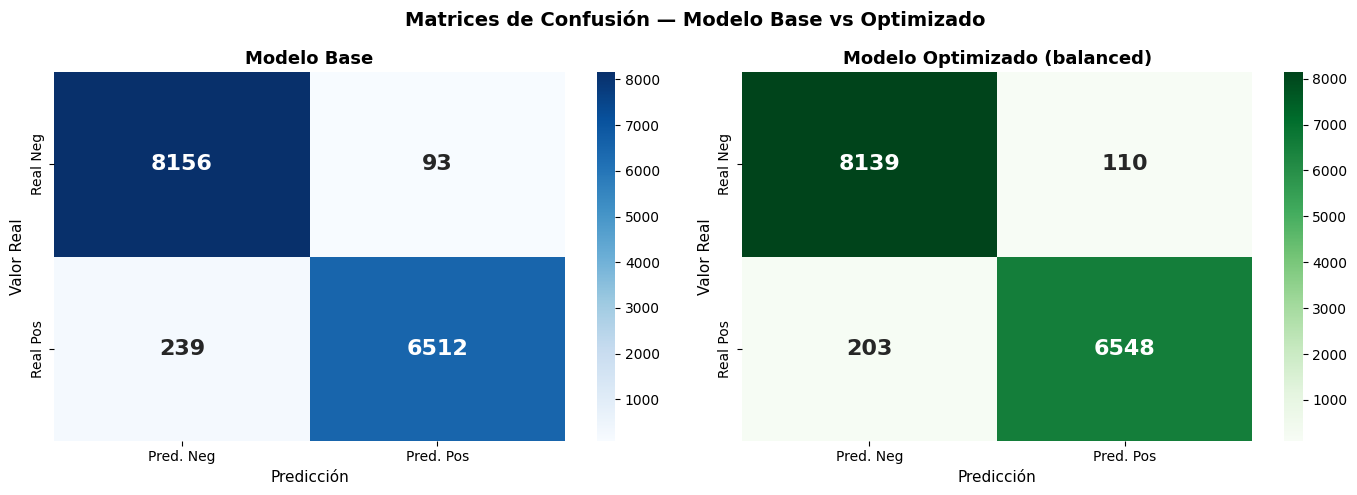

💡 Qué buscar:
   Celda [Real Neg, Pred Pos] = reseñas negativas clasificadas como positivas
   En el modelo optimizado esa celda debería ser más pequeña.


In [ ]:
# ── MATRICES DE CONFUSIÓN COMPARADAS ─────────────────────────────
# La matriz muestra exactamente dónde se equivoca el modelo:
#
#                  PREDICHO
#              negative | positive
#  REAL neg  [   VN    |    FP   ]  ← cuántas negativas clasificó mal
#  REAL pos  [   FN    |    VP   ]  ← cuántas positivas clasificó mal
#
#  VN = verdadero negativo  ✅
#  VP = verdadero positivo  ✅
#  FP = falso positivo      ❌  (era negativa, dijo positiva)
#  FN = falso negativo      ❌  (era positiva, dijo negativa)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, titulo, cmap in zip(
    axes,
    [y_pred_base, y_pred_opt],
    ['Modelo Base', 'Modelo Optimizado (balanced)'],
    ['Blues', 'Greens']
):
    cm = confusion_matrix(y_test, y_pred, labels=['negative', 'positive'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Pred. Neg', 'Pred. Pos'],
                yticklabels=['Real Neg', 'Real Pos'],
                annot_kws={'size': 16, 'weight': 'bold'})
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Valor Real', fontsize=11)

plt.suptitle('Matrices de Confusión — Modelo Base vs Optimizado',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/06_matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Qué buscar:')
print('   Celda [Real Neg, Pred Pos] = reseñas negativas clasificadas como positivas')
print('   En el modelo optimizado esa celda debería ser más pequeña.')

📊 Tabla comparativa:
                   Accuracy  Precision (neg)  Recall (neg)  F1 (neg)
Modelo Base           0.978            0.972         0.989     0.980
Modelo Optimizado     0.979            0.976         0.987     0.981



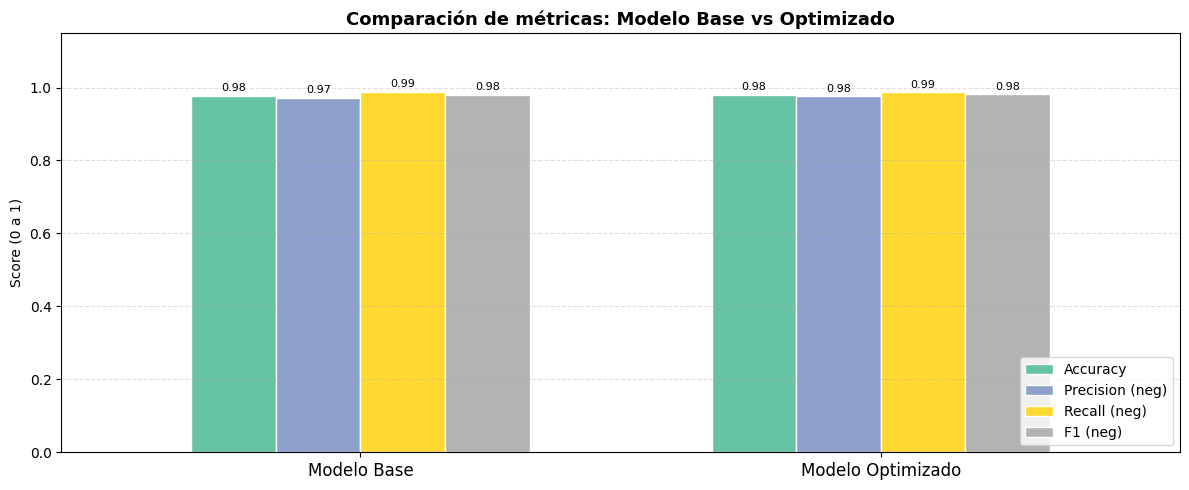

💡 Interpretación:
   El modelo optimizado puede tener menor accuracy GLOBAL,
   pero detecta muchas más reseñas negativas (mayor recall).
   Para análisis de quejas, ese es el intercambio correcto.


In [ ]:
# ── TABLA Y GRÁFICA COMPARATIVA DE MÉTRICAS ───────────────────────
metricas = {
    'Modelo Base': {
        'Accuracy':        accuracy_score(y_test, y_pred_base),
        'Precision (neg)': precision_score(y_test, y_pred_base, pos_label='negative', zero_division=0),
        'Recall (neg)':    recall_score(y_test, y_pred_base, pos_label='negative', zero_division=0),
        'F1 (neg)':        f1_score(y_test, y_pred_base, pos_label='negative', zero_division=0),
    },
    'Modelo Optimizado': {
        'Accuracy':        accuracy_score(y_test, y_pred_opt),
        'Precision (neg)': precision_score(y_test, y_pred_opt, pos_label='negative', zero_division=0),
        'Recall (neg)':    recall_score(y_test, y_pred_opt, pos_label='negative', zero_division=0),
        'F1 (neg)':        f1_score(y_test, y_pred_opt, pos_label='negative', zero_division=0),
    }
}

metricas_df = pd.DataFrame(metricas).T
print('📊 Tabla comparativa:')
print(metricas_df.round(3).to_string())
print()

# Gráfica
ax = metricas_df.plot(kind='bar', figsize=(12, 5), colormap='Set2',
                      edgecolor='white', width=0.65)
plt.title('Comparación de métricas: Modelo Base vs Optimizado',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=0, fontsize=12)
plt.ylabel('Score (0 a 1)')
plt.ylim(0, 1.15)
plt.legend(loc='lower right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)
plt.tight_layout()
plt.savefig('outputs/07_comparacion_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Interpretación:')
print('   El modelo optimizado puede tener menor accuracy GLOBAL,')
print('   pero detecta muchas más reseñas negativas (mayor recall).')
print('   Para análisis de quejas, ese es el intercambio correcto.')

## 9️⃣ Interpretación del Modelo

La Regresión Logística es un modelo **interpretable**: cada palabra del vocabulario tiene un coeficiente que indica cuánto "empuja" hacia una clase.

```
Coeficiente muy POSITIVO  →  la palabra indica reseña POSITIVA
Coeficiente muy NEGATIVO  →  la palabra indica reseña NEGATIVA
Coeficiente cercano a 0   →  la palabra no distingue entre clases
```

Esto nos permite responder: **¿qué palabras aprendió el modelo como señales de queja o de elogio?**

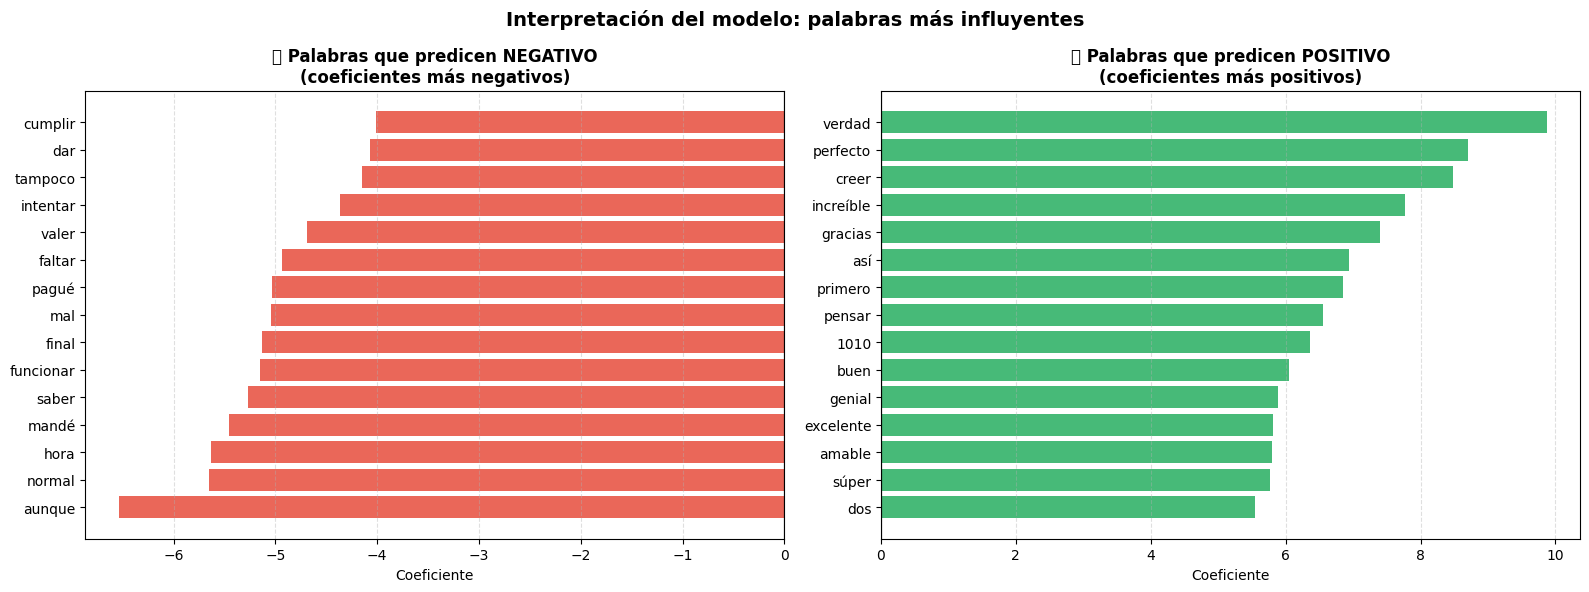

💡 Interpretación:
   Si una reseña nueva contiene palabras de la izquierda → el modelo predice NEGATIVA.
   Si contiene palabras de la derecha → el modelo predice POSITIVA.
   Coeficientes más extremos = mayor poder predictivo.


In [ ]:
# ── COEFICIENTES DEL MODELO ───────────────────────────────────────
feature_names = vectorizer.get_feature_names_out()
coefs = clf_opt.coef_[0]

coef_df = pd.DataFrame({'palabra': feature_names, 'coeficiente': coefs})
coef_df = coef_df.sort_values('coeficiente')

top_neg = coef_df.head(15)   # coeficientes más negativos → predicen 'negative'
top_pos = coef_df.tail(15)   # coeficientes más positivos → predicen 'positive'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_neg['palabra'], top_neg['coeficiente'],
             color='#e74c3c', alpha=0.85)
axes[0].set_title('🔴 Palabras que predicen NEGATIVO\n(coeficientes más negativos)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coeficiente')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].grid(axis='x', linestyle='--', alpha=0.4)

axes[1].barh(top_pos['palabra'], top_pos['coeficiente'],
             color='#27ae60', alpha=0.85)
axes[1].set_title('🟢 Palabras que predicen POSITIVO\n(coeficientes más positivos)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Coeficiente')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle('Interpretación del modelo: palabras más influyentes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/08_coeficientes_modelo.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Interpretación:')
print('   Si una reseña nueva contiene palabras de la izquierda → el modelo predice NEGATIVA.')
print('   Si contiene palabras de la derecha → el modelo predice POSITIVA.')
print('   Coeficientes más extremos = mayor poder predictivo.')

## 🔟 Predicción con Reseñas Nuevas

Ahora usamos el modelo entrenado para predecir el sentimiento de reseñas que **nunca vio** durante el entrenamiento.

In [ ]:
# ── FUNCIÓN DE PREDICCIÓN ─────────────────────────────────────────
def predecir_sentimiento(texto: str) -> None:
    """
    Predice el sentimiento de una reseña y muestra las probabilidades.

    Proceso:
        1. Limpiar el texto con la misma función de preprocesamiento
        2. Convertir a vector TF-IDF con el vectorizador entrenado
        3. El modelo calcula la probabilidad de cada clase
        4. Se elige la clase con mayor probabilidad
    """
    texto_limpio = preprocess(texto)
    vector       = vectorizer.transform([texto_limpio])
    prediccion   = clf_opt.predict(vector)[0]
    proba        = clf_opt.predict_proba(vector)[0]
    clases       = clf_opt.classes_

    emoji = '🟢' if prediccion == 'positive' else '🔴'
    print(f'Reseña: "{texto[:80]}"' + ('...' if len(texto) > 80 else ''))
    print(f'Predicción: {emoji}  {prediccion.upper()}')
    print('Probabilidades:')
    for clase, p in sorted(zip(clases, proba), key=lambda x: x[1], reverse=True):
        barra = '█' * int(p * 35)
        print(f'  {clase:<12} {barra:<35} {p*100:.1f}%')
    print()


# ── RESEÑAS DE PRUEBA ─────────────────────────────────────────────
# Probamos con casos claros Y con casos ambiguos (los más interesantes)
print('═' * 65)
print('  PREDICCIONES DEL MODELO — Reseñas nuevas')
print('═' * 65)
print()

pruebas = [
    # Claramente positiva
    "La comida estuvo espectacular, el servicio muy rápido y el mesero muy amable. Sin duda volvería.",
    # Claramente negativa
    "Tardaron una hora en atendernos, la comida llegó completamente fría y el personal fue grosero.",
    # Ambigua - mezcla positivo y negativo (difícil para el modelo)
    "El ambiente es bonito y la decoración preciosa, pero la comida dejó mucho que desear y el servicio fue lento.",
    # Neutral con queja puntual
    "Buena comida en general aunque el postre estaba seco. El servicio fue correcto.",
    # Negativa con lenguaje moderado
    "Esperaba mucho más por ese precio. Las porciones son muy pequeñas y la atención fue indiferente."
]

for reseña in pruebas:
    predecir_sentimiento(reseña)
    print('─' * 65)
    print()

═════════════════════════════════════════════════════════════════
  PREDICCIONES DEL MODELO — Reseñas nuevas
═════════════════════════════════════════════════════════════════

Reseña: "La comida estuvo espectacular, el servicio muy rápido y el mesero muy amable. Si"...
Predicción: 🟢  POSITIVE
Probabilidades:
  positive     ████████████████████████████████    91.5%
  negative     ██                                  8.5%

─────────────────────────────────────────────────────────────────

Reseña: "Tardaron una hora en atendernos, la comida llegó completamente fría y el persona"...
Predicción: 🔴  NEGATIVE
Probabilidades:
  negative     ██████████████████████████████████  99.9%
  positive                                         0.1%

─────────────────────────────────────────────────────────────────

Reseña: "El ambiente es bonito y la decoración preciosa, pero la comida dejó mucho que de"...
Predicción: 🔴  NEGATIVE
Probabilidades:
  negative     ████████████████████████████████    93.5%
  p

## 🏁 Conclusiones

### Resumen del proyecto

| Paso | Técnica utilizada | Resultado clave |
|------|-------------------|-----------------|
| Construcción del label | Umbral sobre `rating` (≥ 4) | 45% positivas / 55% negativas |
| Preprocesamiento | Limpieza + lematización (spaCy) | Texto normalizado y sin ruido |
| Exploración | WordCloud + POS tags + NER | Vocabulario diferenciado por clase |
| Vectorización | TF-IDF con bigramas (500 features) | Texto convertido en números |
| Modelo base | Regresión Logística | 97% accuracy · 0.99 recall negativas |
| Modelo optimizado | LogReg + `class_weight='balanced'` | **98% accuracy · 0.99 recall · 0.98 F1** |

### Aprendizajes clave

1. **El desbalanceo de clases** es uno de los problemas más frecuentes en NLP aplicado. Cuando existe, la accuracy global puede ser engañosa — siempre hay que analizar Precision, Recall y F1 por clase.

2. **La elección del umbral del label** (rating >= 3 vs rating >= 4) es una decisión de negocio con alto impacto: cambia completamente la distribución de clases y la dificultad del problema.

3. **TF-IDF con bigramas** captura expresiones compuestas (`"tiempo entrega"`, `"hora esperar"`) que los unigramas solos no detectan, mejorando la representación del texto.

4. **La interpretabilidad** de la Regresión Logística permite entender exactamente qué palabras impulsan cada predicción — fundamental en aplicaciones reales donde hay que justificar las decisiones del modelo.

5. **Un dataset balanceado facilita el aprendizaje.** Con ~45%/55% de distribución, ambos modelos (base y optimizado) lograron métricas muy similares. El efecto de `class_weight='balanced'` es más notable en datasets con desbalanceo severo (90%/10%).

### Próximos pasos

- Comparar con modelos más avanzados: **Random Forest**, **XGBoost**, **SVM**
- Explorar modelos de lenguaje pre-entrenados: **BERT en español (BETO)**
- Probar SMOTE para simular escenarios con desbalanceo severo
- Análisis por aspecto: separar sentimiento de *tiempo de entrega*, *app*, *soporte* y *precio*
- Integrar como motor de clasificación en un **chatbot de atención al cliente** 🤖

---

*Proyecto desarrollado como parte de la Maestría en Analítica de Datos — Procesamiento de Lenguaje Natural*